In [1]:
from fenics import *
import numpy as np
import matplotlib.pyplot as plt
import math
import networkx as nx

/home/harsh/anaconda3/envs/fenics_work/lib/python3.11/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
n = 64
alpha = 1e-5

In [3]:
cont_a = np.load(f"fem_model/a_opt_{n}_{alpha}.npy")      # shape = (n*n,)
cont_c = np.load(f"fem_model/c_opt_{n}_{alpha}.npy")      # shape = ((n+1)*(n+1),)

In [4]:
a = np.load(f"fem_model/a_disc_{n}_{alpha}.npy")      # shape = (n*n,)
c = np.load(f"fem_model/u_disc_{n}_{alpha}.npy")      # shape = ((n+1)*(n+1),)

(array([1751., 1171., 1043., 1162.,  857.,  573.,  285.,  226.,  230.,
         894.]),
 array([0.05214275, 0.14607656, 0.24001038, 0.33394419, 0.427878  ,
        0.52181182, 0.61574563, 0.70967945, 0.80361326, 0.89754708,
        0.99148089]),
 <BarContainer object of 10 artists>)

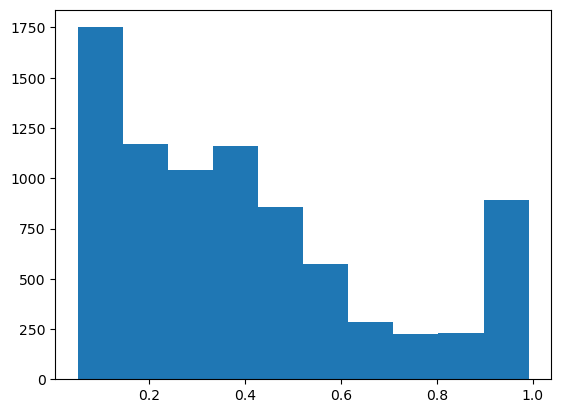

In [5]:
plt.hist(cont_a)

In [6]:
n = int(math.sqrt(len(cont_a)/2))
V = 0.4

In [7]:
K = int(2 * n * n * V)                  # number of 1's allowed
idx_sorted = np.argsort(cont_a)[::-1]   # sort indices by value descending

# Pick the top K indices
top_idx = idx_sorted[:K]

# Create binary discrete a
a = np.zeros_like(cont_a, dtype=int)
a[top_idx] = 1
a.sum()/len(a)
np.save(f"fem_model/a_disc_{n}_{alpha}.npy", a)

In [8]:
def _build_graph(n_x, n_y):
        G = nx.Graph()
        N = n_x * n_y
        G.add_nodes_from(range(N))
        for k in range(0, N, 2):
            if k + 1 < N:
                G.add_edge(k, k + 1)
            if (k + 2) % n_y != 0 and k + 3 < N:
                G.add_edge(k, k + 3)
            if (k // n_y) != 0:
                nb = k - (n_y - 1)
                if nb >= 0:
                    G.add_edge(k, nb)
        return G

In [9]:
obj_expr = 0.0
f = 0.01
h = 1/n
graph = _build_graph(n, 2*n)
tri_area_weight = f * (h*h / 6.0)   # f * (A_T/3)

scale = np.zeros(len(graph.edges()))
for k, (u, v) in enumerate(graph.edges()):
    scale[k] = math.sqrt(2) if abs(u - v) == 1 else 1.0


def node_idx_2d_to_1d(i, j, n):
    """Map node (i,j) → global 1D node index."""
    return i + j * (n+1)


for I in range(n):
        for J in range(n):

            # -------- Lower triangle L(I,J) --------
            # vertices: (I,J), (I+1,J), (I+1,J+1)
            vL = [
                (I,   J),
                (I+1, J),
                (I+1, J+1)
            ]

            for (i, j) in vL:
                k = node_idx_2d_to_1d(i, j, n)
                obj_expr += tri_area_weight * c[k]

            # -------- Upper triangle U(I,J) --------
            # vertices: (I,J), (I+1,J+1), (I,J+1)
            vU = [
                (I,   J),
                (I+1, J+1),
                (I,   J+1)
            ]

            for (i, j) in vU:
                k = node_idx_2d_to_1d(i, j, n)
                obj_expr += tri_area_weight * c[k]


In [ ]:
# def build_graph(n_x, n_y):
#         N = n_x * n_y
#         graph = nx.Graph()
#         graph.add_nodes_from(range(N))

#         for k in range(0, N, 2):
#             if k + 1 < N:
#                 graph.add_edge(k, k + 1)
#             if (k + 2) % n_y != 0 and k + 3 < N:
#                 graph.add_edge(k, k + 3)
#             if (k // n_y) != 0:
#                 nb = k - (n_y - 1)
#                 if nb >= 0:
#                     graph.add_edge(k, nb)

#         return graph

# graph = build_graph(n, 2*n)

# # precompute the per-edge scale factors
# # (so you dont recompute abs(u-v)==1 each iteration)
# scale = np.zeros(len(graph.edges()))
# for k, (u, v) in enumerate(graph.edges()):
#     scale[k] = math.sqrt(2) if abs(u - v) == 1 else 1.0

# def compute_TV(a, b):
#         """Total variation term at (a,b,lam,rho)"""
#         # note: lam, rho arent used here  but signature stays same
#         diffs = []
#         for (u, v), s in zip(graph.edges(), scale):
#             diffs.append(s * abs(a[u] - a[v]))
#         Gg = sum(diffs)
#         return  Gg

# tv = compute_TV(cont_a, cont_a)
# print(tv)

392.4603784886466


In [10]:
diffs = []
for (u, v), s in zip(graph.edges(), scale):
    diffs.append(s * abs(a[u] - a[v]))
Gg = sum(diffs)
s_TV = (1.0 / math.sqrt(len(a)//2)) * Gg * alpha

expr=obj_expr + s_TV

In [11]:
print("net Obj:",expr)
print("compliance:",obj_expr)
print("TV", (s_TV * math.sqrt(len(a)//2)/alpha)) 

net Obj: 0.004737092222743935
compliance: 0.0046446336188788895
TV 591.7350647362952


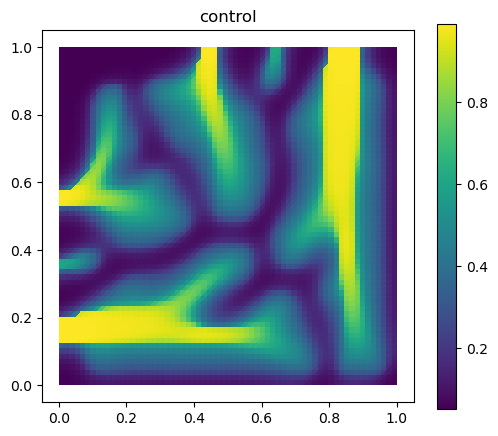

In [12]:
mesh = UnitSquareMesh(n, n)
A = FunctionSpace(mesh, "DG", 0)

a_func = Function(A)
a_func.vector().set_local(cont_a)

# Plot using matplotlib backend
fig = plt.figure(figsize=(6,5))
p = plot(a_func, cmap='viridis')   # or any matplotlib colormap

plt.colorbar(p)  # <-- add colorbar
plt.title("control")
#plt.xlabel("x")
#plt.ylabel("y")

plt.show()


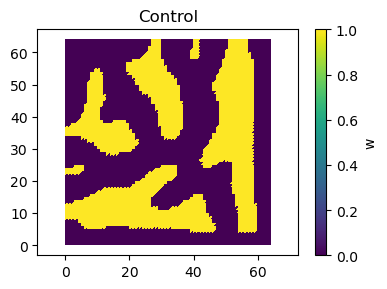

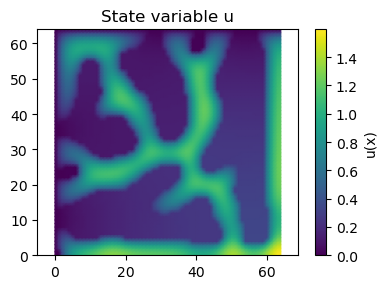

In [13]:
# --- reconstruct node coordinates ---
X, Y = np.meshgrid(np.arange(n+1), np.arange(n+1))
x_nodes = X.flatten()
y_nodes = Y.flatten()

# --- build triangle list ---
triangles = []
tri_vals = []

for I in range(n):
    for J in range(n):

        # lower triangle L(I,J)   vertices: (I,J), (I+1,J), (I+1,J+1)
        tri_L = [
            [I,   J],
            [I+1, J],
            [I+1, J+1]
        ]
        idx_L = 2*(I + J*n)
        triangles.append(tri_L)
        tri_vals.append(a[idx_L])

        # upper triangle U(I,J)   vertices: (I,J), (I+1,J+1), (I, J+1)
        tri_U = [
            [I,   J],
            [I+1, J+1],
            [I,   J+1]
        ]
        idx_U = 2*(I + J*n) + 1
        triangles.append(tri_U)
        tri_vals.append(a[idx_U])

# convert triangle nodes to a global list of points
points = []
tri_indices = []
for tri in triangles:
    idxs = []
    for (i,j) in tri:
        points.append([i, j])
        idxs.append(len(points)-1)
    tri_indices.append(idxs)

points = np.array(points)
tri_indices = np.array(tri_indices)
tri_vals = np.array(tri_vals)


# ---------------------------
#       Plot a (triangles)
# ---------------------------
plt.figure(figsize=(4,3))
plt.tripcolor(points[:,0], points[:,1], tri_indices, tri_vals,
                shading="flat", cmap="viridis")
plt.colorbar(label="w")
plt.title("Control")
plt.axis("equal")
plt.tight_layout()


# ---------------------------
#         Plot u (nodes)
# ---------------------------
c_grid = c.reshape((n+1, n+1))

plt.figure(figsize=(4,3))
plt.pcolormesh(X, Y, c_grid, shading="gouraud", cmap="viridis")
plt.colorbar(label="u(x)")
plt.title("State variable u")
plt.axis("equal")
plt.tight_layout()

plt.show()


In [14]:
import networkx as nx
from fenics import *
import numpy as np
import math

In [ ]:
def build_mesh_graph(mesh):
    G = nx.Graph()
    num_cells = mesh.num_cells()
    G.add_nodes_from(range(num_cells))

    # get the connectivity: cell → facets → neighboring cells
    mesh.init(2, 1)
    mesh.init(1, 2)

    for cell in cells(mesh):
        cid = cell.index()
        for facet in facets(cell):
            for neighbor in facet.entities(2):
                if neighbor != cid:
                    G.add_edge(cid, neighbor)

    return G

In [16]:
mesh = UnitSquareMesh(3,3)
G = build_mesh_graph(mesh)

In [17]:
scale = np.zeros(len(G.edges()))
for k, (u, v) in enumerate(G.edges()):
    scale[k] = math.sqrt(2) if abs(u - v) == 1 else 1.0

In [18]:
for (u, v), s in zip(G.edges(), scale):
    print(f"Nodes: {u}, {v}; Weight: {s}")

Nodes: 0, 3; Weight: 1.0
Nodes: 0, 1; Weight: 1.4142135623730951
Nodes: 1, 6; Weight: 1.0
Nodes: 2, 5; Weight: 1.0
Nodes: 2, 3; Weight: 1.4142135623730951
Nodes: 3, 8; Weight: 1.0
Nodes: 4, 5; Weight: 1.4142135623730951
Nodes: 5, 10; Weight: 1.0
Nodes: 6, 9; Weight: 1.0
Nodes: 6, 7; Weight: 1.4142135623730951
Nodes: 7, 12; Weight: 1.0
Nodes: 8, 11; Weight: 1.0
Nodes: 8, 9; Weight: 1.4142135623730951
Nodes: 9, 14; Weight: 1.0
Nodes: 10, 11; Weight: 1.4142135623730951
Nodes: 11, 16; Weight: 1.0
Nodes: 12, 15; Weight: 1.0
Nodes: 12, 13; Weight: 1.4142135623730951
Nodes: 14, 17; Weight: 1.0
Nodes: 14, 15; Weight: 1.4142135623730951
Nodes: 16, 17; Weight: 1.4142135623730951


In [ ]:
def check_graph_against_V(G, V):
    n = V.dim()
    bad = [(i,j) for i,j in G.edges() if i >= n or j >= n or i < 0 or j < 0]
    print("Graph edges:", len(G.edges()))
    print("V.dim():", n)
    print("Bad edges:", len(bad))
    if bad:
        print("Example bad edge:", bad[0])

In [ ]:
check_graph_against_V(G, )